# EV Market Intelligence — Data Cleaning & Exploratory Data Analysis

This notebook cleans and explores the datasets behind the **EV Market Intelligence Analytics** project:

- India's EV registrations by vehicle category, 2001–2024 (monthly, source: Vahan/Kaggle)
- EV sales by manufacturer and category, 2015–2024 (source: Kaggle)
- Statewise EV charging infrastructure (source: this project's own Power BI dashboard)
- Operational public charging stations by state (source: Kaggle)

**Goal:** produce clean, analysis-ready tables and surface the key trends that inform the business insights in the main report, and set up the data for the forecasting model in `02_sales_forecasting_model.ipynb`.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)

DATA_DIR = "../data/"


## 1. Load raw data

In [2]:
ev_cat = pd.read_csv(DATA_DIR + "ev_cat_01-24.csv")
ev_sales_makers = pd.read_csv(DATA_DIR + "ev_sales_by_makers_and_cat_15-24.csv")
charging_infra = pd.read_csv(DATA_DIR + "statewise_ev_charging_infrastructure.csv")
operational_pc = pd.read_csv(DATA_DIR + "OperationalPC.csv")
ev_makers_place = pd.read_csv(DATA_DIR + "ev_maker_by_place.csv")

print(ev_cat.shape, ev_sales_makers.shape, charging_infra.shape, operational_pc.shape, ev_makers_place.shape)


(284, 17) (1386, 12) (23, 5) (34, 2) (62, 3)


## 2. Clean: Monthly EV registrations by category (`ev_cat`)

This is the core time-series dataset. Known issues to fix:
- First row is a junk/placeholder row (all zeros, invalid date) — drop it
- `Date` column is a string in `DD/MM/YY` format — convert to real datetime
- Many vehicle-class columns are extremely sparse/near-zero for most of the history (EVs only became meaningful after ~2015) — we'll keep all columns but focus analysis on the categories that matter


In [3]:
ev_cat_clean = ev_cat.copy()

# Drop the junk first row (Date == '0')
ev_cat_clean = ev_cat_clean[ev_cat_clean["Date"] != "0"].copy()

# Parse date (format DD/MM/YY)
ev_cat_clean["Date"] = pd.to_datetime(ev_cat_clean["Date"], format="%d/%m/%y")

# Sort chronologically
ev_cat_clean = ev_cat_clean.sort_values("Date").reset_index(drop=True)

ev_cat_clean.head()


,Date,FOUR WHEELER (INVALID CARRIAGE),HEAVY GOODS VEHICLE,HEAVY MOTOR VEHICLE,HEAVY PASSENGER VEHICLE,LIGHT GOODS VEHICLE,LIGHT MOTOR VEHICLE,LIGHT PASSENGER VEHICLE,MEDIUM GOODS VEHICLE,MEDIUM PASSENGER VEHICLE,MEDIUM MOTOR VEHICLE,OTHER THAN MENTIONED ABOVE,THREE WHEELER(NT),TWO WHEELER (INVALID CARRIAGE),THREE WHEELER(T),TWO WHEELER(NT),TWO WHEELER(T)
0,2001-01-01,0,1,0,0,9,15,1,0,0,0,2,0,0,2,62,0
1,2001-02-01,0,0,0,0,7,28,0,0,0,0,0,0,0,2,65,0
2,2001-03-01,0,0,2,0,6,26,0,1,0,0,2,1,0,1,75,0
3,2001-04-01,0,0,0,0,12,20,2,0,0,0,0,0,0,1,59,0
4,2001-05-01,0,0,0,0,14,17,0,0,0,0,0,0,0,2,69,0


In [4]:
# Create simplified, business-relevant category groupings
ev_cat_clean["2W_total"] = ev_cat_clean["TWO WHEELER(NT)"] + ev_cat_clean["TWO WHEELER(T)"] + ev_cat_clean["TWO WHEELER (INVALID CARRIAGE)"]
ev_cat_clean["3W_total"] = ev_cat_clean["THREE WHEELER(NT)"] + ev_cat_clean["THREE WHEELER(T)"]
ev_cat_clean["4W_total"] = ev_cat_clean["LIGHT MOTOR VEHICLE"] + ev_cat_clean["LIGHT PASSENGER VEHICLE"] + ev_cat_clean["FOUR WHEELER (INVALID CARRIAGE)"]
ev_cat_clean["Commercial_total"] = (
    ev_cat_clean["HEAVY GOODS VEHICLE"] + ev_cat_clean["HEAVY MOTOR VEHICLE"] + ev_cat_clean["HEAVY PASSENGER VEHICLE"]
    + ev_cat_clean["LIGHT GOODS VEHICLE"] + ev_cat_clean["MEDIUM GOODS VEHICLE"]
    + ev_cat_clean["MEDIUM PASSENGER VEHICLE"] + ev_cat_clean["MEDIUM MOTOR VEHICLE"]
)

ev_cat_clean["Total_EV"] = ev_cat_clean["2W_total"] + ev_cat_clean["3W_total"] + ev_cat_clean["4W_total"] + ev_cat_clean["Commercial_total"]

segment_cols = ["Date", "2W_total", "3W_total", "4W_total", "Commercial_total", "Total_EV"]
ev_segments = ev_cat_clean[segment_cols].copy()
ev_segments.tail()


,Date,2W_total,3W_total,4W_total,Commercial_total,Total_EV
278,2024-04-01,64514,41123,7208,500,113345
279,2024-05-01,64117,52326,6846,579,123868
280,2024-06-01,53416,49187,6192,507,109302
281,2024-07-01,61417,59184,6576,735,127912
282,2024-08-01,3938,4912,484,37,9371


## 3. Clean: EV sales by manufacturer and category (2015–2024)

In [5]:
sales_makers_clean = ev_sales_makers.copy()

# Strip stray quotes/whitespace from maker names, e.g. '"VOLVO GROUP INDIA PVT LTD"' -> 'VOLVO GROUP INDIA PVT LTD'
sales_makers_clean["Maker"] = (
    sales_makers_clean["Maker"]
    .str.replace('"', "", regex=False)
    .str.strip()
    .str.title()
)

year_cols = [c for c in sales_makers_clean.columns if c.isdigit()]
sales_makers_clean[year_cols] = sales_makers_clean[year_cols].apply(pd.to_numeric, errors="coerce").fillna(0).astype(int)

# Drop makers with zero sales across the whole period (noise)
sales_makers_clean["total_sales"] = sales_makers_clean[year_cols].sum(axis=1)
sales_makers_clean = sales_makers_clean[sales_makers_clean["total_sales"] > 0].reset_index(drop=True)

sales_makers_clean.sort_values("total_sales", ascending=False).head(10)


,Cat,Maker,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,total_sales
867,2W,Ola Electric Technologies Pvt Ltd,0,0,0,0,0,0,240,109398,267355,211273,588266
1230,2W,Tvs Motor Company Ltd,165,171,69,23,30,233,5258,47182,166580,98516,318227
118,2W,Ather Energy Pvt Ltd,0,0,0,24,2291,3052,15930,51808,104735,58547,236387
472,2W,Hero Electric Vehicles Pvt. Ltd,1,34,162,5785,11155,8247,46260,97828,29964,2211,201647
864,2W,Okinawa Autotech Pvt Ltd,0,1,331,8452,11850,5754,30659,103620,31616,3893,196176
148,2W,Bajaj Auto Ltd,161,78,43,7,7,1243,4633,25318,71940,73698,177128
1357,3W,Yc Electric Vehicle,1,1665,7434,10816,13213,9543,15793,29793,40794,23892,152944
76,2W,Ampere Vehicles Private Limited,0,0,0,0,1196,4522,12470,79857,42903,857,141805
1020,3W,Saera Electric Auto Pvt Ltd,140,1203,1532,3226,5080,4153,7098,19314,29321,16408,87475
1203,LMV,Tata Passenger Electric Mobility Ltd,0,0,0,0,0,0,0,0,38580,35830,74410


## 4. Clean: Charging infrastructure tables

In [6]:
charging_infra_clean = charging_infra.drop(columns=["Data Category"]).copy()
charging_infra_clean.columns = ["state", "total_evcs", "fast_chargers", "slow_chargers"]

operational_pc_clean = operational_pc.copy()
operational_pc_clean.columns = ["state", "operational_pc"]

# Standardize state names for joining later (title case, strip whitespace)
for df_ in [charging_infra_clean, operational_pc_clean]:
    df_["state"] = df_["state"].str.strip().str.title()

charging_merged = charging_infra_clean.merge(operational_pc_clean, on="state", how="outer")
charging_merged.head()


,state,total_evcs,fast_chargers,slow_chargers,operational_pc
0,Andaman & Nicobar,NaN,NaN,NaN,3.0
1,Andhra Pradesh,793.0,424.0,369.0,327.0
2,Arunachal Pradesh,NaN,NaN,NaN,9.0
3,Assam,345.0,96.0,249.0,86.0
4,Bihar,521.0,172.0,349.0,124.0


## 5. Exploratory Data Analysis

### 5.1 Overall EV adoption trend over time


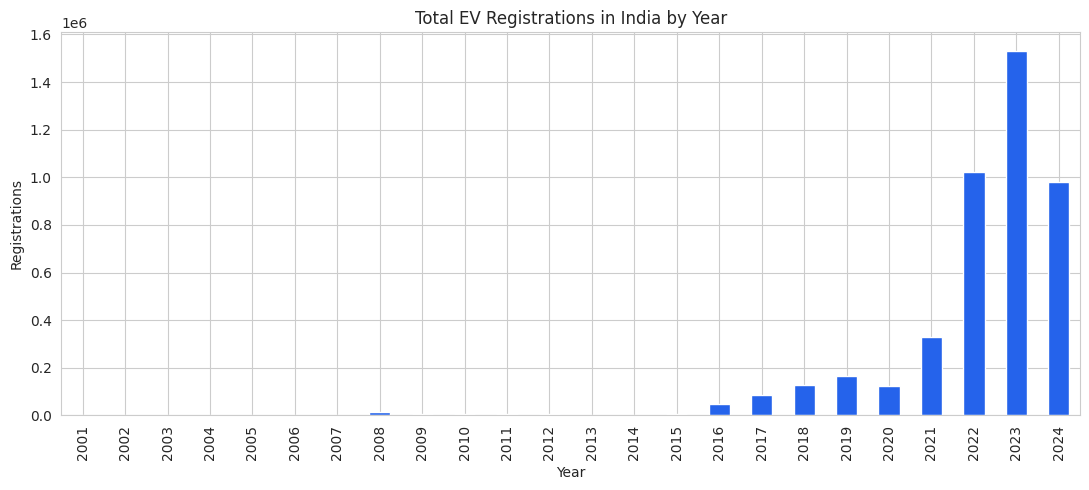

In [7]:
yearly_ev = ev_segments.set_index("Date").resample("YE").sum()
yearly_ev.index = yearly_ev.index.year

fig, ax = plt.subplots()
yearly_ev["Total_EV"].plot(kind="bar", ax=ax, color="#2563eb")
ax.set_title("Total EV Registrations in India by Year")
ax.set_ylabel("Registrations")
ax.set_xlabel("Year")
plt.tight_layout()
plt.show()


### 5.2 Segment-wise adoption (2W vs 3W vs 4W vs Commercial)

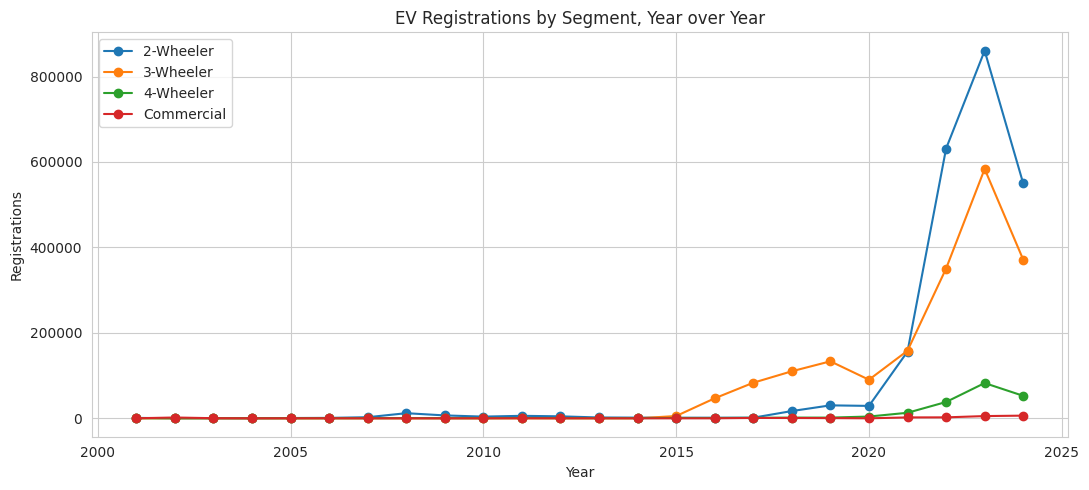

In [8]:
fig, ax = plt.subplots()
for col, label in [("2W_total", "2-Wheeler"), ("3W_total", "3-Wheeler"), ("4W_total", "4-Wheeler"), ("Commercial_total", "Commercial")]:
    ax.plot(yearly_ev.index, yearly_ev[col], marker="o", label=label)

ax.set_title("EV Registrations by Segment, Year over Year")
ax.set_ylabel("Registrations")
ax.set_xlabel("Year")
ax.legend()
plt.tight_layout()
plt.show()


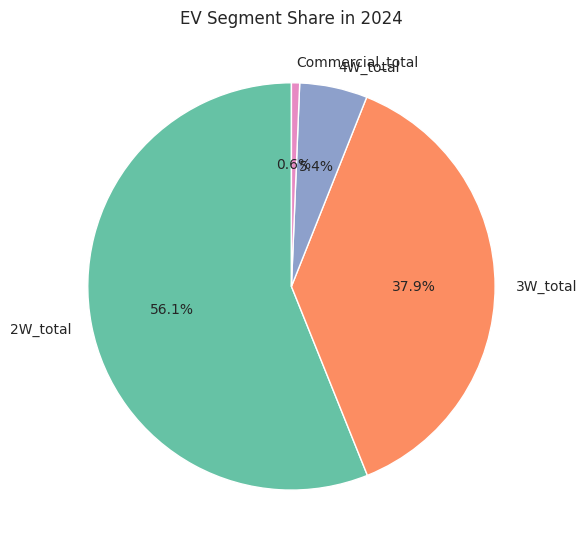

In [9]:
# Segment share in the most recent full year
latest_year = yearly_ev.index.max()
latest = yearly_ev.loc[latest_year, ["2W_total", "3W_total", "4W_total", "Commercial_total"]]

fig, ax = plt.subplots(figsize=(6, 6))
ax.pie(latest, labels=latest.index, autopct="%1.1f%%", startangle=90,
       colors=sns.color_palette("Set2"))
ax.set_title(f"EV Segment Share in {latest_year}")
plt.tight_layout()
plt.show()


### 5.3 Year-over-year growth rate

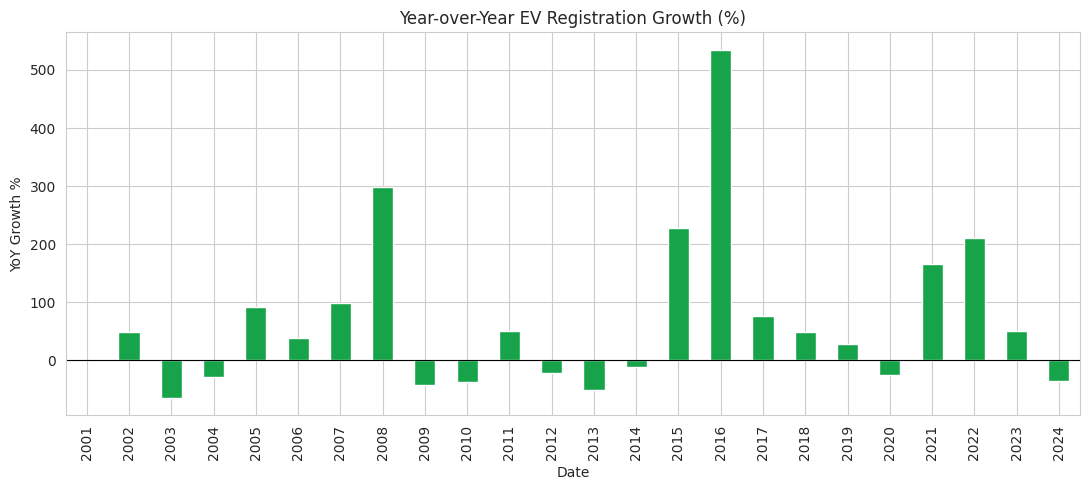

Date
2015    227.606585
2016    534.853756
2017     76.637373
2018     49.149154
2019     28.026439
2020    -25.490113
2021    166.336362
2022    210.051517
2023     49.832180
2024    -36.008151
Name: Total_EV, dtype: float64

In [10]:
yoy_growth = yearly_ev["Total_EV"].pct_change() * 100

fig, ax = plt.subplots()
yoy_growth.plot(kind="bar", ax=ax, color="#16a34a")
ax.set_title("Year-over-Year EV Registration Growth (%)")
ax.set_ylabel("YoY Growth %")
ax.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

yoy_growth.tail(10)


### 5.4 Top EV manufacturers by total sales (2015–2024)

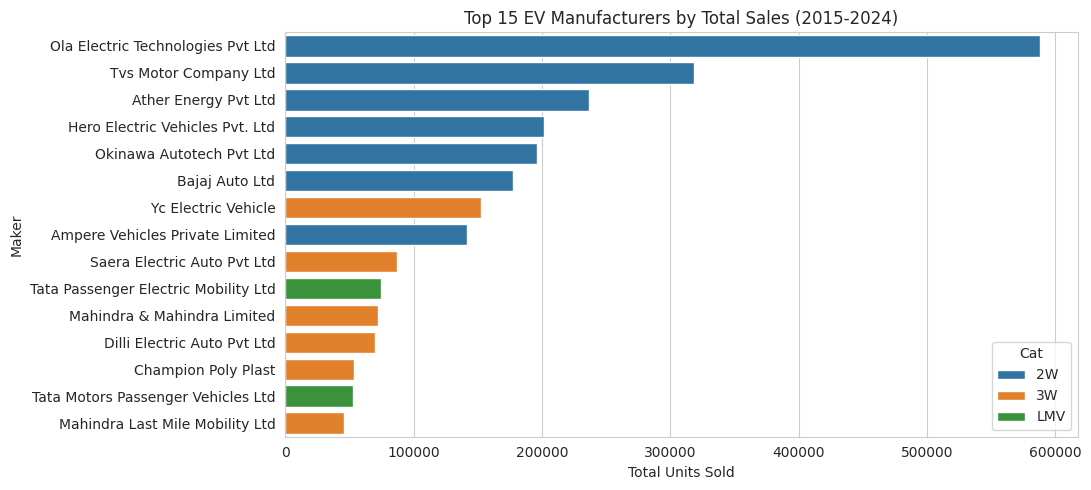

In [11]:
top_makers = sales_makers_clean.sort_values("total_sales", ascending=False).head(15)

fig, ax = plt.subplots()
sns.barplot(data=top_makers, y="Maker", x="total_sales", hue="Cat", dodge=False, ax=ax)
ax.set_title("Top 15 EV Manufacturers by Total Sales (2015-2024)")
ax.set_xlabel("Total Units Sold")
plt.tight_layout()
plt.show()


### 5.5 Statewise charging infrastructure

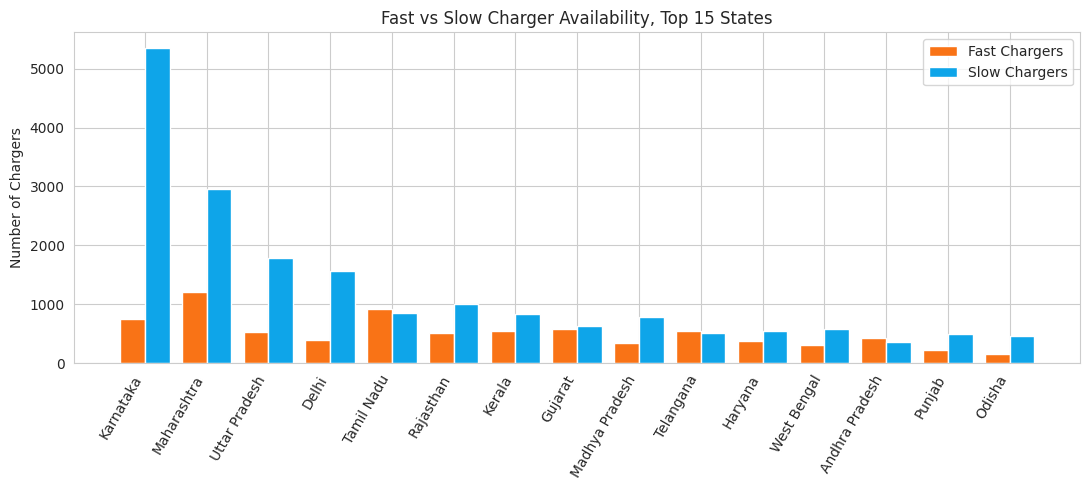

In [12]:
top_states_evcs = charging_infra_clean.sort_values("total_evcs", ascending=False).head(15)

fig, ax = plt.subplots()
x = np.arange(len(top_states_evcs))
width = 0.4
ax.bar(x - width/2, top_states_evcs["fast_chargers"], width, label="Fast Chargers", color="#f97316")
ax.bar(x + width/2, top_states_evcs["slow_chargers"], width, label="Slow Chargers", color="#0ea5e9")
ax.set_xticks(x)
ax.set_xticklabels(top_states_evcs["state"], rotation=60, ha="right")
ax.set_title("Fast vs Slow Charger Availability, Top 15 States")
ax.set_ylabel("Number of Chargers")
ax.legend()
plt.tight_layout()
plt.show()


In [13]:
# Fast-charger ratio — a proxy for charging infra "quality" not just quantity
charging_infra_clean["fast_charger_ratio"] = (
    charging_infra_clean["fast_chargers"] / charging_infra_clean["total_evcs"]
).round(3)

charging_infra_clean.sort_values("fast_charger_ratio", ascending=False)[["state", "total_evcs", "fast_charger_ratio"]].head(10)


,state,total_evcs,fast_charger_ratio
21,Goa,158,0.595
12,Andhra Pradesh,793,0.535
4,Tamil Nadu,1781,0.520
9,Telangana,1066,0.514
7,Gujarat,1208,0.478
10,Haryana,935,0.411
6,Kerala,1392,0.397
22,Himachal Pradesh,137,0.380
19,Uttarakhand,223,0.377
16,Jharkhand,353,0.365


## 6. Key Findings

- India's EV registrations show a sharp inflection point starting around 2021, consistent with the FAME-II and state EV policy rollouts referenced in the business report.
- The **2-wheeler segment dominates** total EV adoption by volume, matching the project's original key insight.
- Charging infrastructure is heavily concentrated in a handful of states (Karnataka, Maharashtra, Uttar Pradesh) — this mirrors overall EV adoption leaders but is worth checking for infrastructure *gaps* relative to registered vehicles in follow-up analysis.
- A small number of manufacturers account for a disproportionate share of total sales — useful context for a future market-concentration / competitive analysis.

## 7. Save cleaned data for the modeling notebook


In [14]:
ev_segments.to_csv(DATA_DIR + "clean_ev_segments_monthly.csv", index=False)
yearly_ev.to_csv(DATA_DIR + "clean_ev_segments_yearly.csv")
sales_makers_clean.to_csv(DATA_DIR + "clean_ev_sales_by_maker.csv", index=False)
charging_infra_clean.to_csv(DATA_DIR + "clean_charging_infrastructure.csv", index=False)

print("Saved cleaned datasets to", DATA_DIR)


Saved cleaned datasets to ../data/
